# Problema 4 — Otimização mista da rede hidráulica

Este notebook apresenta a implementação do **Problema 4**, no qual existe um número limitado de canos grossos, de menor resistência hidráulica, e é necessário decidir em quais arestas da rede eles devem ser instalados.

A métrica otimizada é a amplitude das pressões nodais:

\[
\min \left(\max_i p_i - \min_i p_i\right).
\]

A apresentação contém três estudos computacionais:

1. **Caso 1:** rede com 20 nós, usada para mostrar a resolução por MILP;
2. **Caso 2:** rede com 100 nós e poucas arestas, mantendo o problema maior, mas tratável;
3. **Caso 3:** mesmo tipo de formulação com limite de tempo artificialmente muito baixo, mostrando que o código retorna a melhor solução viável encontrada ou uma solução heurística de fallback.

## 1. Formulação usada

Para cada aresta \(e\in E\), define-se a variável binária

\[
x_e=
\begin{cases}
1, & \text{se a aresta recebe cano grosso},\\
0, & \text{se a aresta permanece com cano fino}.
\end{cases}
\]

Se existem \(\mathcal{C}\) canos grossos disponíveis, impõe-se

\[
\sum_{e\in E}x_e=\mathcal{C}.
\]

A lei constitutiva depende da escolha do tipo de cano:

\[
q_e=k_e^f(Mp)_e, \quad \text{se } x_e=0,
\]

\[
q_e=k_e^g(Mp)_e, \quad \text{se } x_e=1.
\]

Essa condição lógica é implementada com restrições Big-\(M\). O objetivo é minimizar \(z\), onde \(z\) representa a diferença entre a maior e a menor pressão nodal.

## 2. Importações

Para este notebook funcionar, o arquivo `ProblemaP4.py` deve estar dentro da pasta `src/` do projeto. A célula seguinte também aplica, em tempo de execução, a atualização que permite aceitar soluções viáveis quando o solver para por limite de tempo e usar uma heurística quando nenhuma solução viável é retornada.

In [1]:
from pathlib import Path
import sys
import inspect
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from IPython.display import display

try:
    import pandas as pd
except ImportError:
    pd = None

project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.ProblemGeneratorP1 import ProblemaP1Generator
from src.ProblemaP4 import ProblemaP4

## 3. Atualização da classe `ProblemaP4`

A atualização abaixo mantém a compatibilidade com versões anteriores da classe. Se a sua classe já tiver os novos argumentos `accept_feasible` e `use_fallback`, a célula não altera nada. Caso contrário, ela adiciona os métodos necessários em tempo de execução.

In [2]:
def aplicar_atualizacao_problema_p4():
    assinatura = inspect.signature(ProblemaP4.solve_milp)
    if "accept_feasible" in assinatura.parameters:
        return False

    def solve_milp(self, accept_feasible=True, use_fallback=True):
        c_obj, integrality, bounds, constraints, metadata = self._build_milp()

        result = self.__class__.__dict__["_milp_solver"](
            c=c_obj,
            integrality=integrality,
            bounds=bounds,
            constraints=constraints,
            options=self.solver_options,
        )

        self.p4_result = result

        if result.success:
            self.solution_status = "otima"
            self.solution_is_optimal = True
            self._load_solution(result.x, metadata)
            return self.summary()

        if accept_feasible and result.x is not None:
            idx = metadata["idx"]
            x_raw = np.asarray(result.x[idx["x"]], dtype=float)
            x_round = np.rint(x_raw)
            is_integral = np.allclose(x_raw, x_round, atol=1e-5)

            if self.use_exact_number:
                count_ok = int(np.sum(x_round)) == int(self.max_thick_pipes)
            else:
                count_ok = int(np.sum(x_round)) <= int(self.max_thick_pipes)

            if is_integral and count_ok:
                self.solution_status = "viavel_nao_certificada"
                self.solution_is_optimal = False
                self._load_solution(result.x, metadata)
                return self.summary()

        if use_fallback:
            self.solution_status = "heuristica"
            self.solution_is_optimal = False
            candidate = self._heuristic_pressure_drop_solution()
            self._load_candidate_solution(candidate)
            return self.summary()

        raise RuntimeError(f"o solver nao retornou solucao utilizavel: {result.message}")

    def solve(self, accept_feasible=True, use_fallback=True):
        return self.solve_milp(accept_feasible=accept_feasible, use_fallback=use_fallback)

    def _heuristic_pressure_drop_solution(self):
        self._ensure_ready()

        if self.fine_conductivities is None or self.thick_conductivities is None:
            self._compute_fine_and_thick_conductivities()

        edge_list = self.get_edge_list()
        p_fine, _ = self._solve_linear_with_conductivities(self.fine_conductivities)
        pressure_drops = np.abs(self.A @ p_fine)

        n_select = min(self.max_thick_pipes, self.num_edges)
        selected_indices = np.argsort(-pressure_drops)[:n_select]
        selected_edges = [edge_list[i] for i in selected_indices]

        return self.evaluate_configuration(thick_edges=selected_edges)

    def _load_candidate_solution(self, candidate):
        if self.fine_conductivities is None or self.thick_conductivities is None:
            self._compute_fine_and_thick_conductivities()

        edge_list = self.get_edge_list()
        thick_set = set(candidate["thick_edges"])

        x = np.array([1 if edge in thick_set else 0 for edge in edge_list], dtype=int)
        conductivities = self.fine_conductivities + (self.thick_conductivities - self.fine_conductivities) * x

        self.x_solution = x
        self.selected_thick_edges = list(candidate["thick_edges"])
        self.objective_value = float(candidate["pressure_range"])

        self.K = diags(conductivities, offsets=0, format="csr", dtype=float)
        self.M = (self.A.T @ self.K @ self.A).tocsr()
        self.p = np.asarray(candidate["pressures"], dtype=float)

        self._update_node_pressures()
        self._compute_edge_flows()

        for e, (u, v) in enumerate(edge_list):
            attrs = self.edges[u][v]
            attrs["x_grosso"] = int(x[e])
            attrs["tipo_cano"] = "grosso" if x[e] == 1 else "fino"
            attrs["area_original"] = float(attrs["area"])
            attrs["area_usada"] = float(attrs["area"] * (self.thick_area_factor if x[e] == 1 else 1.0))
            attrs["condutancia_usada"] = float(conductivities[e])

    def summary(self):
        if self.p is None or self.x_solution is None:
            raise ValueError("execute solve_milp antes de chamar summary")

        return {
            "objective_pressure_range": float(np.max(self.p) - np.min(self.p)),
            "solver_objective": float(self.objective_value),
            "pressure_min": float(np.min(self.p)),
            "pressure_max": float(np.max(self.p)),
            "max_thick_pipes": int(self.max_thick_pipes),
            "n_thick_used": int(np.sum(self.x_solution)),
            "selected_thick_edges": list(self.selected_thick_edges),
            "solution_status": getattr(self, "solution_status", None),
            "solution_is_optimal": getattr(self, "solution_is_optimal", None),
            "solver_status": getattr(self.p4_result, "status", None) if self.p4_result is not None else None,
            "solver_message": getattr(self.p4_result, "message", None) if self.p4_result is not None else None,
            "mip_gap": getattr(self.p4_result, "mip_gap", None) if self.p4_result is not None else None,
        }

    from scipy.optimize import milp as scipy_milp
    ProblemaP4._milp_solver = staticmethod(scipy_milp)
    ProblemaP4.solve_milp = solve_milp
    ProblemaP4.solve = solve
    ProblemaP4._heuristic_pressure_drop_solution = _heuristic_pressure_drop_solution
    ProblemaP4._load_candidate_solution = _load_candidate_solution
    ProblemaP4.summary = summary

    return True

patch_aplicado = aplicar_atualizacao_problema_p4()
print("atualizacao aplicada:", patch_aplicado)

atualizacao aplicada: False


## 4. Funções auxiliares da apresentação

As funções abaixo reduzem repetição no notebook. Elas geram uma rede, resolvem o P1 de referência, resolvem o P4 e exibem tabelas comparativas.

In [3]:
def gerar_rede(seed, num_nodes, edge_prob):
    generator = ProblemaP1Generator(seed=seed)
    p1 = generator.generate(
        num_nodes=num_nodes,
        edge_prob=edge_prob,
        mu=1e-3,
        patm=0.0,
        q_mode="uniform",
        single_sink=True,
    )
    p1.setup()
    p1.solve()
    return p1


def mostrar_resumo_p1(p1, nome):
    print(nome)
    print("numero de nos:", p1.num_nodes)
    print("numero de arestas:", p1.num_edges)
    print("pressao minima p1:", float(np.min(p1.p)), "Pa")
    print("pressao maxima p1:", float(np.max(p1.p)), "Pa")
    print("amplitude de pressao p1:", float(np.max(p1.p) - np.min(p1.p)), "Pa")


def resolver_caso_p4(p1, nome, time_limit, mip_rel_gap=1e-4, disp=False):
    p4 = ProblemaP4(
        p1_instance=p1,
        max_thick_pipes=3,
        thick_area_factor=2.0,
        use_exact_number=True,
        pressure_bound_factor=5.0,
        big_m_factor=1.05,
        solver_options={
            "disp": disp,
            "time_limit": time_limit,
            "mip_rel_gap": mip_rel_gap,
        },
    )

    baseline = p4.evaluate_configuration(thick_edges=[])
    summary = p4.solve_milp(accept_feasible=True, use_fallback=True)

    comparison = {
        "caso": ["todos finos", "p4 otimizado"],
        "nos": [p1.num_nodes, p1.num_nodes],
        "arestas": [p1.num_edges, p1.num_edges],
        "pressao_minima_pa": [baseline["pressure_min"], summary["pressure_min"]],
        "pressao_maxima_pa": [baseline["pressure_max"], summary["pressure_max"]],
        "amplitude_pressao_pa": [baseline["pressure_range"], summary["objective_pressure_range"]],
    }

    reduction = (
        (baseline["pressure_range"] - summary["objective_pressure_range"])
        / baseline["pressure_range"]
        * 100
    )

    print(nome)
    print("status da solucao:", summary["solution_status"])
    print("solucao otima certificada:", summary["solution_is_optimal"])
    print("mensagem do solver:", summary["solver_message"])
    print("gap mip:", summary["mip_gap"])
    print("reducao percentual:", reduction, "%")
    print("arestas grossas selecionadas:", summary["selected_thick_edges"])

    if pd is not None:
        comparison_df = pd.DataFrame(comparison)
        display(comparison_df)
    else:
        print(comparison)

    return p4, baseline, summary

## 5. Caso 1 — rede com 20 nós

Este caso é usado para apresentar a solução por otimização mista em uma rede de tamanho pequeno/médio. Ele mantém a ideia dos testes anteriores: poucos canos grossos são escolhidos entre todas as arestas disponíveis.

In [4]:
p1_20 = gerar_rede(
    seed=42,
    num_nodes=20,
    edge_prob=0.10,
)

mostrar_resumo_p1(p1_20, "caso 1: rede com 20 nos")

caso 1: rede com 20 nos
numero de nos: 20
numero de arestas: 35
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.3048756532124219 Pa
amplitude de pressao p1: 0.3048756532124219 Pa


In [5]:
p4_20, baseline_20, summary_20 = resolver_caso_p4(
    p1=p1_20,
    nome="caso 1: p4 com 20 nos",
    time_limit=300,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 1: p4 com 20 nos
status da solucao: otima
solucao otima certificada: True
mensagem do solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
gap mip: 0.0
reducao percentual: 61.97160337465347 %
arestas grossas selecionadas: [('node_1', 'node_5'), ('node_4', 'node_5'), ('node_15', 'node_17')]


,caso,nos,arestas,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,20,35,0.0,0.304876,0.304876
1,p4 otimizado,20,35,0.0,0.115939,0.115939


### 5.1. Arestas escolhidas no caso de 20 nós

In [6]:
edge_rows_20 = p4_20.edge_solution_table()

if pd is not None:
    edge_df_20 = pd.DataFrame(edge_rows_20)
    display(edge_df_20.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_20:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
5,"(node_1, node_5)",grosso,1,1.4017,2.8034,3.83,81.645359,0.035665,2.911862
32,"(node_15, node_17)",grosso,1,0.7114,1.4228,4.21,19.132237,-0.043110,-0.824793
18,"(node_4, node_5)",grosso,1,1.3201,2.6402,1.74,159.398616,-0.023496,-3.745184
0,"(node_0, node_1)",fino,0,1.0618,1.0618,4.80,9.345539,0.023856,0.222951
2,"(node_0, node_13)",fino,0,1.1841,1.1841,4.14,13.475242,-0.003241,-0.043675
3,"(node_0, node_14)",fino,0,0.7995,0.7995,3.06,8.311428,-0.007094,-0.058963
4,"(node_0, node_19)",fino,0,0.9569,0.9569,1.39,26.210690,-0.001457,-0.038185
1,"(node_0, node_2)",fino,0,1.5980,1.5980,3.39,29.971880,0.008248,0.247196
9,"(node_1, node_10)",fino,0,1.1479,1.1479,2.16,24.272500,-0.009505,-0.230700
11,"(node_1, node_11)",fino,0,1.5263,1.5263,2.76,33.583880,-0.020206,-0.678587


### 5.2. Pressões nodais no caso de 20 nós

In [7]:
node_rows_20 = p4_20.node_solution_table()

if pd is not None:
    node_df_20 = pd.DataFrame(node_rows_20)
    display(node_df_20.sort_values("pressao", ascending=False))
else:
    for row in node_rows_20:
        print(row)

,node,pressao,fluxo_externo
17,node_17,0.115939,1.052736
18,node_18,0.090871,0.275474
14,node_14,0.090111,0.175664
9,node_9,0.087722,0.446271
12,node_12,0.086284,0.022717
13,node_13,0.086258,0.002381
6,node_6,0.084762,0.088048
19,node_19,0.084474,0.021951
16,node_16,0.083912,0.041684
0,node_0,0.083017,0.329324


### 5.3. Visualização do caso de 20 nós

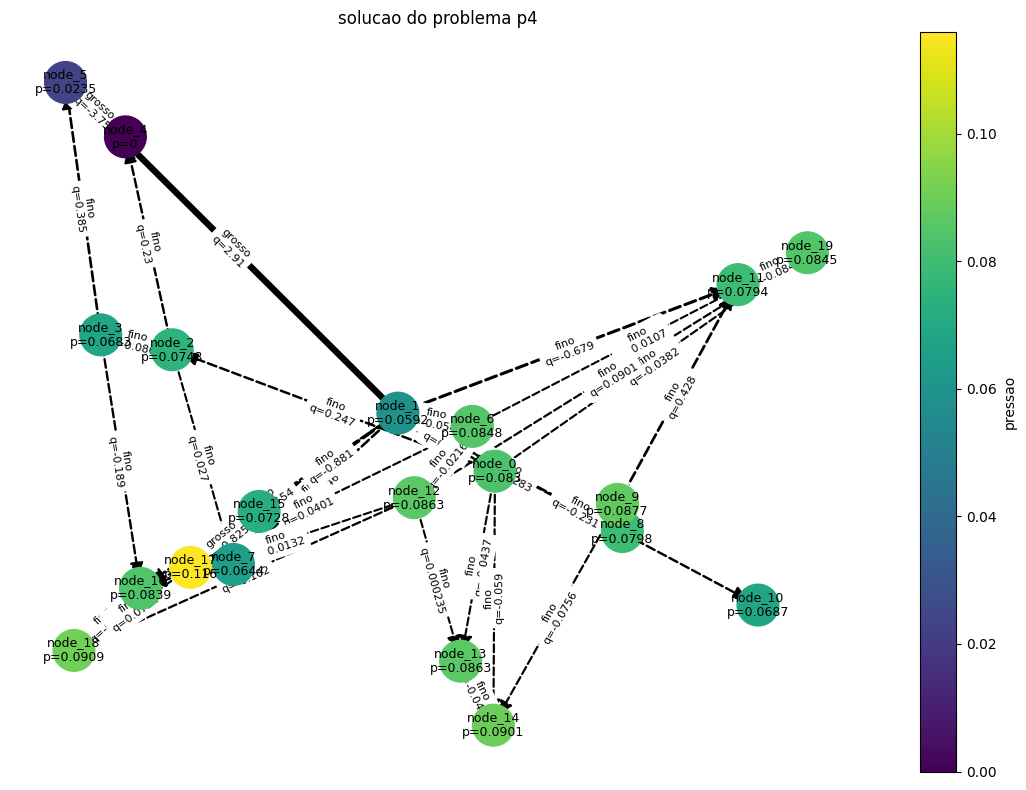

In [8]:
p4_20.plot_solution(
    layout="spring",
    figsize=(11, 8),
    show_labels=True,
)
plt.show()

## 6. Caso 2 — rede com 100 nós e poucas arestas

Este caso mantém 100 nós, mas reduz a probabilidade de conexão para controlar o número de arestas. Isso é importante porque a dificuldade do problema misto cresce fortemente com o número de variáveis binárias, isto é, com o número de arestas.

In [9]:
p1_100 = gerar_rede(
    seed=42,
    num_nodes=100,
    edge_prob=0.006,
)

mostrar_resumo_p1(p1_100, "caso 2: rede com 100 nos e poucas arestas")

caso 2: rede com 100 nos e poucas arestas
numero de nos: 100
numero de arestas: 119
pressao minima p1: 0.0 Pa
pressao maxima p1: 0.2883803928543435 Pa
amplitude de pressao p1: 0.2883803928543435 Pa


In [10]:
p4_100, baseline_100, summary_100 = resolver_caso_p4(
    p1=p1_100,
    nome="caso 2: p4 com 100 nos e poucas arestas",
    time_limit=300,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 2: p4 com 100 nos e poucas arestas
status da solucao: otima
solucao otima certificada: True
mensagem do solver: Optimization terminated successfully. (HiGHS Status 7: Optimal)
gap mip: 8.147976840379204e-05
reducao percentual: 35.31374863235836 %
arestas grossas selecionadas: [('node_20', 'node_22'), ('node_46', 'node_82'), ('node_47', 'node_77')]


,caso,nos,arestas,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,119,0.0,0.288380,0.288380
1,p4 otimizado,100,119,0.0,0.186542,0.186542


### 6.1. Arestas escolhidas no caso de 100 nós

In [11]:
edge_rows_100 = p4_100.edge_solution_table()

if pd is not None:
    edge_df_100 = pd.DataFrame(edge_rows_100)
    display(edge_df_100.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_100:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
52,"(node_20, node_22)",grosso,1,0.5516,1.1032,4.64,10.436399,-0.017484,-0.182468
96,"(node_46, node_82)",grosso,1,0.6405,1.2810,2.47,26.433912,0.042333,1.119038
97,"(node_47, node_77)",grosso,1,0.7173,1.4346,2.96,27.664962,0.045439,1.257078
0,"(node_0, node_1)",fino,0,1.0618,1.0618,4.80,9.345539,-0.016632,-0.155439
2,"(node_0, node_13)",fino,0,1.1841,1.1841,4.14,13.475242,0.013737,0.185110
...,...,...,...,...,...,...,...,...,...
117,"(node_87, node_95)",fino,0,1.2945,1.2945,1.97,33.845273,0.008298,0.280852
118,"(node_88, node_92)",fino,0,1.8870,1.8870,4.51,31.414301,-0.000265,-0.008332
35,"(node_9, node_11)",fino,0,1.4178,1.4178,1.56,51.270256,-0.000437,-0.022409
36,"(node_9, node_37)",fino,0,0.5083,0.5083,4.26,2.413186,0.031724,0.076555


### 6.2. Pressões nodais no caso de 100 nós

In [12]:
node_rows_100 = p4_100.node_solution_table()

if pd is not None:
    node_df_100 = pd.DataFrame(node_rows_100)
    display(node_df_100.sort_values("pressao", ascending=False))
else:
    for row in node_rows_100:
        print(row)

,node,pressao,fluxo_externo
78,node_78,0.186542,0.011189
45,node_45,0.186401,0.081218
44,node_44,0.186096,0.048352
65,node_65,0.185158,0.085772
83,node_83,0.184581,0.030988
...,...,...,...
86,node_86,0.050947,0.008552
31,node_31,0.050847,0.031021
27,node_27,0.049075,0.032394
46,node_46,0.042333,0.005529


## 7. Caso 3 — limite de tempo e retorno de solução não ótima

Este caso mostra a funcionalidade nova. O limite de tempo é colocado artificialmente muito baixo. Com isso, o solver pode parar antes de certificar otimalidade. A implementação então segue a ordem:

1. usa a solução ótima, se ela foi certificada;
2. aceita a melhor solução inteira viável retornada pelo solver, se existir;
3. se o solver não retornar solução viável, usa uma heurística baseada nas maiores quedas de pressão da rede com todos os canos finos.

O objetivo deste caso não é produzir o melhor resultado possível, mas mostrar que o notebook continua retornando uma configuração admissível.

In [13]:
p4_timeout, baseline_timeout, summary_timeout = resolver_caso_p4(
    p1=p1_100,
    nome="caso 3: limite de tempo artificialmente baixo",
    time_limit=1e-9,
    mip_rel_gap=1e-4,
    disp=False,
)

caso 3: limite de tempo artificialmente baixo
status da solucao: heuristica
solucao otima certificada: False
mensagem do solver: Time limit reached. (HiGHS Status 13: model_status is Time limit reached; primal_status is At lower/fixed bound)
gap mip: None
reducao percentual: 30.23087113251166 %
arestas grossas selecionadas: [('node_27', 'node_34'), ('node_46', 'node_82'), ('node_47', 'node_77')]


,caso,nos,arestas,pressao_minima_pa,pressao_maxima_pa,amplitude_pressao_pa
0,todos finos,100,119,0.0,0.28838,0.28838
1,p4 otimizado,100,119,0.0,0.20120,0.20120


### 7.1. Interpretação do status

A chave `solution_status` resume o tipo de solução retornada:

- `otima`: o solver certificou otimalidade global;
- `viavel_nao_certificada`: o solver parou antes da certificação, mas retornou uma solução inteira viável;
- `heuristica`: o solver não retornou solução inteira viável aproveitável e foi usada a heurística de fallback.

In [14]:
summary_timeout

{'objective_pressure_range': 0.20120048791911607,
 'solver_objective': 0.20120048791911607,
 'pressure_min': 0.0,
 'pressure_max': 0.20120048791911607,
 'max_thick_pipes': 3,
 'n_thick_used': 3,
 'selected_thick_edges': [('node_27', 'node_34'),
  ('node_46', 'node_82'),
  ('node_47', 'node_77')],
 'solution_status': 'heuristica',
 'solution_is_optimal': False,
 'solver_message': 'Time limit reached. (HiGHS Status 13: model_status is Time limit reached; primal_status is At lower/fixed bound)',
 'mip_gap': None}

### 7.2. Arestas escolhidas no caso com limite de tempo

In [15]:
edge_rows_timeout = p4_timeout.edge_solution_table()

if pd is not None:
    edge_df_timeout = pd.DataFrame(edge_rows_timeout)
    display(edge_df_timeout.sort_values(["x_grosso", "edge"], ascending=[False, True]))
else:
    for row in edge_rows_timeout:
        print(row)

,edge,tipo_cano,x_grosso,area_original,area_usada,length,condutancia_usada,delta_pressao,vazao
69,"(node_27, node_34)",grosso,1,0.7114,1.4228,4.21,19.132237,-0.025356,-0.485109
96,"(node_46, node_82)",grosso,1,0.6405,1.2810,2.47,26.433912,0.040654,1.074636
97,"(node_47, node_77)",grosso,1,0.7173,1.4346,2.96,27.664962,0.042654,1.180031
0,"(node_0, node_1)",fino,0,1.0618,1.0618,4.80,9.345539,-0.011094,-0.103676
2,"(node_0, node_13)",fino,0,1.1841,1.1841,4.14,13.475242,0.013395,0.180499
...,...,...,...,...,...,...,...,...,...
117,"(node_87, node_95)",fino,0,1.2945,1.2945,1.97,33.845273,0.008048,0.272376
118,"(node_88, node_92)",fino,0,1.8870,1.8870,4.51,31.414301,-0.000265,-0.008332
35,"(node_9, node_11)",fino,0,1.4178,1.4178,1.56,51.270256,-0.000437,-0.022409
36,"(node_9, node_37)",fino,0,0.5083,0.5083,4.26,2.413186,0.028677,0.069202


## 8. Verificação por força bruta para redes pequenas

Para redes pequenas, é possível comparar a solução do MILP com uma busca exaustiva. Essa etapa é opcional, pois o número de combinações cresce rapidamente com o número de arestas.

In [16]:
run_brute_force_check = False

if run_brute_force_check:
    brute = p4_20.brute_force_check(max_combinations=200000)
    print("amplitude p4:", p4_20.summary()["objective_pressure_range"])
    print("amplitude forca bruta:", brute["pressure_range"])
    print("arestas p4:", p4_20.summary()["selected_thick_edges"])
    print("arestas forca bruta:", brute["thick_edges"])